# Visualizations & Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 7)
sns.set_style('whitegrid')
sns.set_palette('husl')

data_path = Path('../data')

In [2]:
df = pd.read_csv(data_path/'cleaned_yrbs_data.csv')

print(df.shape)
print(df.columns.tolist())

(15694, 35)
['age', 'gender', 'education_level', 'ride_drinking_driver', 'school_safety_concern', 'threatened_at_school', 'fight_count', 'school_fight_count', 'neighborhood_violence', 'sexual_violence', 'school_racism', 'school_bullying', 'cyber_bullying', 'feel_hopeless', 'considered_suicide', 'first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row', 'exercise', 'social_media', 'mental_health', 'hours_of_sleep', 'sleep_place', 'grade', 'parent_emotional_abuse', 'parent_physical_abuse', 'parent_abuse_parent', 'parent_uses_alcohol', 'parent_mental_illness', 'incarcerated_parent', 'have_friend', 'parent_monitoring', 'unfair_discipline_school', 'ADHD']


In [3]:
df.shape

(15694, 35)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15694 entries, 0 to 15693
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         15694 non-null  float64
 1   gender                      15694 non-null  str    
 2   education_level             15694 non-null  str    
 3   ride_drinking_driver        15694 non-null  float64
 4   school_safety_concern       15694 non-null  float64
 5   threatened_at_school        15694 non-null  float64
 6   fight_count                 15694 non-null  float64
 7   school_fight_count          15694 non-null  float64
 8   neighborhood_violence       15694 non-null  float64
 9   sexual_violence             15694 non-null  float64
 10  school_racism               15694 non-null  float64
 11  school_bullying             15694 non-null  float64
 12  cyber_bullying              15694 non-null  float64
 13  feel_hopeless               15694 non-null

In [5]:
df.describe().round(3)

,age,ride_drinking_driver,school_safety_concern,threatened_at_school,fight_count,school_fight_count,neighborhood_violence,sexual_violence,school_racism,school_bullying,...,parent_emotional_abuse,parent_physical_abuse,parent_abuse_parent,parent_uses_alcohol,parent_mental_illness,incarcerated_parent,have_friend,parent_monitoring,unfair_discipline_school,ADHD
count,15694.000,15694.000,15694.000,15694.000,15694.00,15694.000,15694.000,15694.000,15694.000,15694.000,...,15694.000,15694.000,15694.000,15694.000,15694.000,15694.000,15694.000,15694.000,15694.000,15694.000
mean,15.941,0.188,0.057,0.222,0.32,0.138,0.012,0.024,0.466,0.197,...,1.099,0.320,0.226,0.192,0.216,0.120,2.614,3.142,0.128,0.314
std,1.217,0.611,0.231,1.138,1.30,0.835,0.610,0.671,0.887,0.414,...,0.931,0.695,0.624,0.394,0.411,0.325,0.957,0.795,0.334,0.464
min,12.000,0.000,0.000,0.000,0.00,0.000,-1.000,-1.000,0.000,-1.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,15.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,2.000,3.000,0.000,0.000
50%,16.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,0.000,0.000,...,1.000,0.000,0.000,0.000,0.000,0.000,3.000,3.000,0.000,0.000
75%,17.000,0.000,0.000,0.000,0.00,0.000,0.000,0.000,1.000,0.000,...,1.000,0.000,0.000,0.000,0.000,0.000,3.000,4.000,0.000,1.000
max,18.000,4.000,1.000,12.000,12.00,12.000,1.000,4.000,4.000,1.000,...,4.000,4.000,4.000,1.000,1.000,1.000,4.000,4.000,1.000,1.000


## Grade Distribution

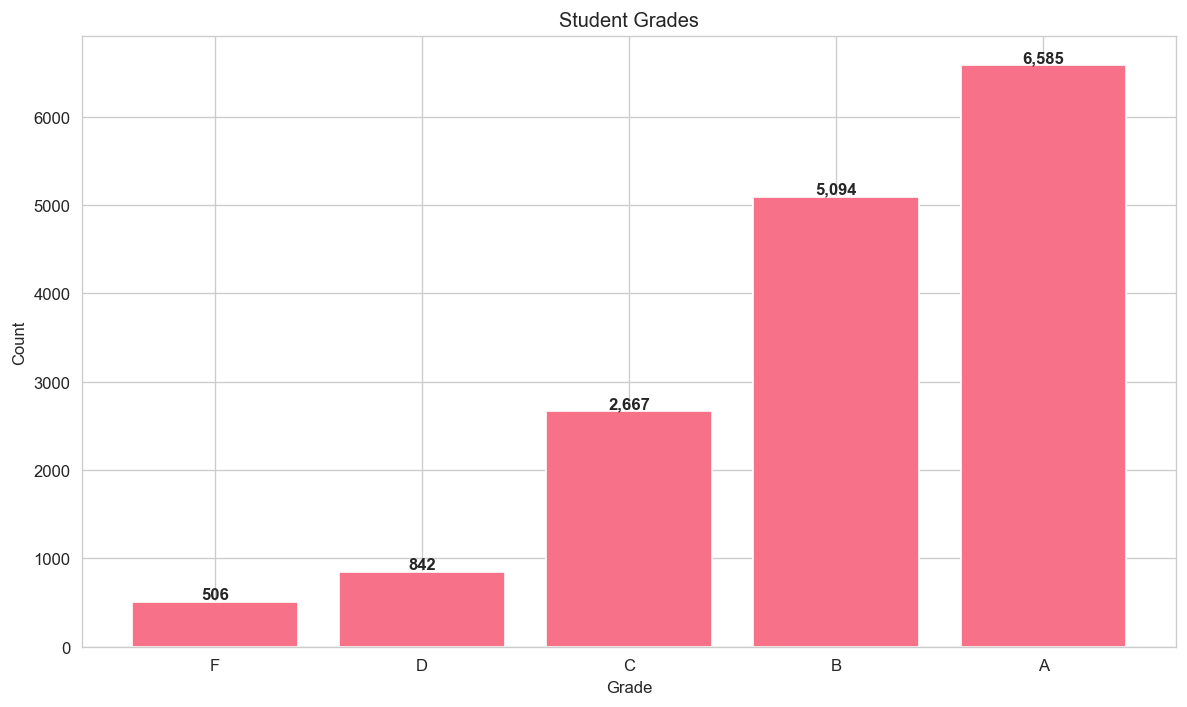

  F: 506 (3.2%)
  D: 842 (5.4%)
  C: 2,667 (17.0%)
  B: 5,094 (32.5%)
  A: 6,585 (42.0%)


In [6]:
# Target variable distribution
grade_map = {0: 'F', 1: 'D', 2: 'C', 3: 'B', 4: 'A'}
grade_counts = df['grade'].value_counts().sort_index()
grade_labels = [grade_map[int(g)] for g in grade_counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(grade_labels, grade_counts.values)
ax.set_title('Student Grades')
ax.set_xlabel('Grade')
ax.set_ylabel('Count')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

for grade, count in grade_counts.items():
    print(f"  {grade_map[grade]}: {count:,} ({count/grade_counts.sum()*100:.1f}%)")

## Correlation Matrix

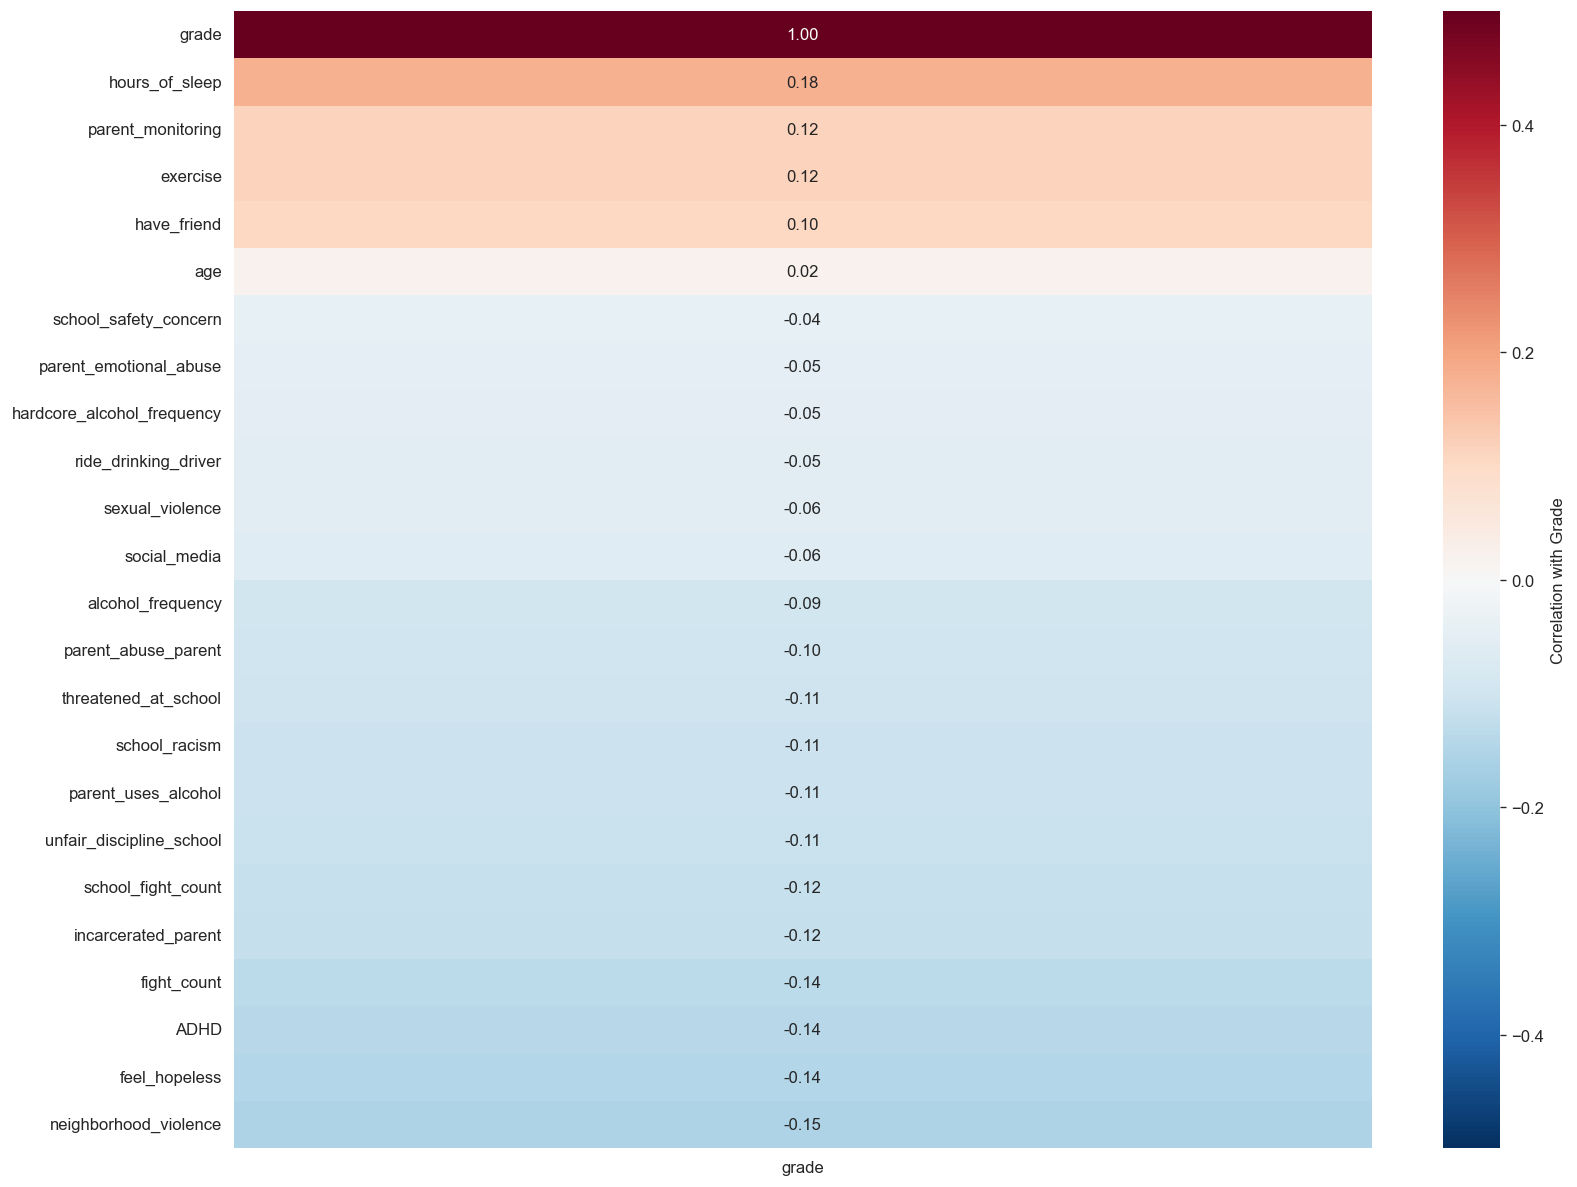

2. hours_of_sleep                : +0.179
3. parent_monitoring             : +0.117
4. exercise                      : +0.115
5. have_friend                   : +0.104
6. age                           : +0.022
7. school_safety_concern         : -0.040
8. parent_emotional_abuse        : -0.051
9. hardcore_alcohol_frequency    : -0.054
10. ride_drinking_driver          : -0.055


In [7]:
fig, ax = plt.subplots(figsize=(14, 10))
df_numeric = df.select_dtypes(include=[np.number])
corr_matrix = df_numeric.corr()

grade_corr = corr_matrix['grade'].sort_values(ascending=False)
top_bottom = pd.concat([grade_corr.head(12), grade_corr.tail(12)])
sns.heatmap(top_bottom.to_frame(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            cbar_kws={'label': 'Correlation with Grade'}, ax=ax, vmin=-0.5, vmax=0.5)
plt.tight_layout()
plt.show()

for i, (feature, corr) in enumerate(grade_corr.head(10).items(), 1):
    if feature != 'grade':
        print(f"{i}. {feature:30s}: {corr:+.3f}")

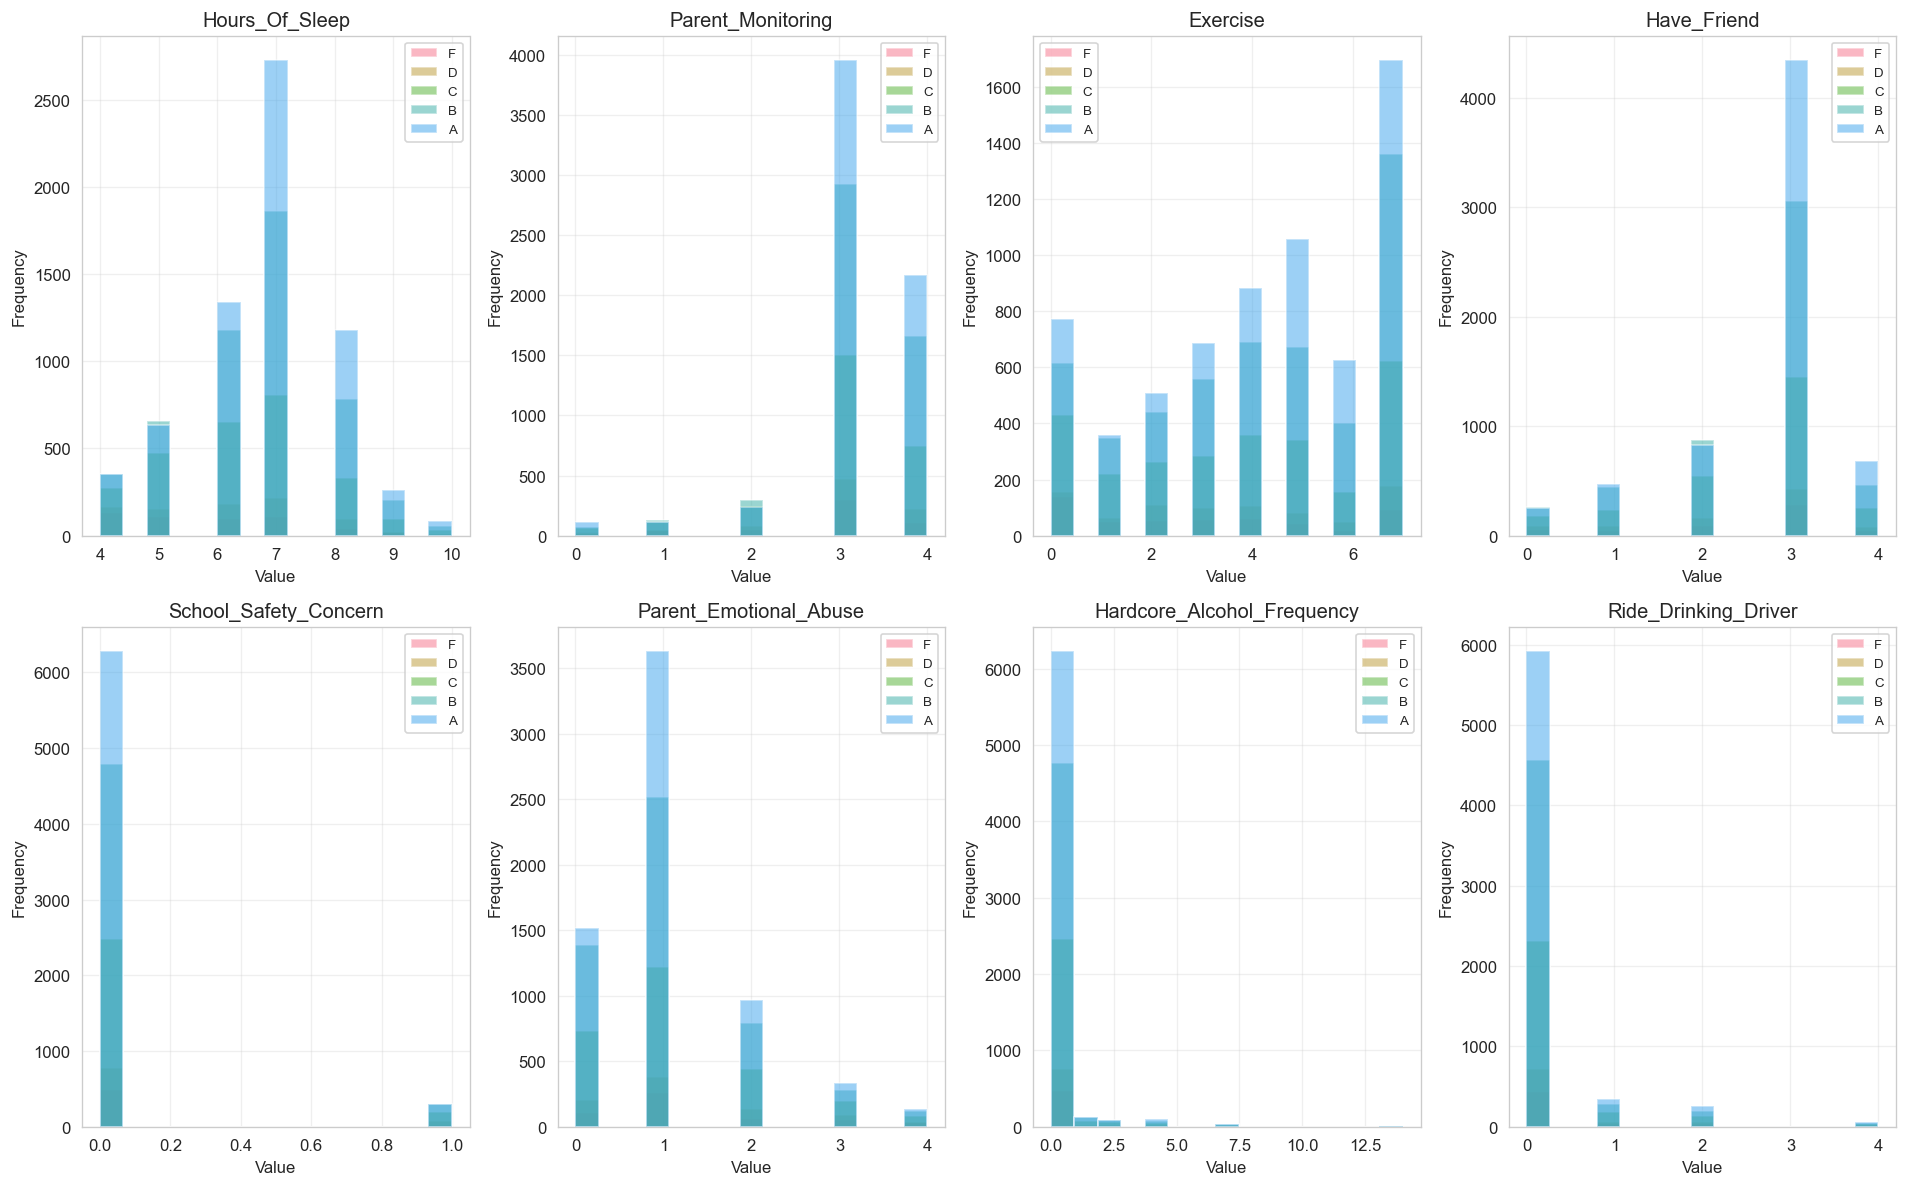

In [8]:
key_features = ['hours_of_sleep', 'parent_monitoring', 'exercise', 'have_friend', 'school_safety_concern', 'parent_emotional_abuse', 
                'hardcore_alcohol_frequency', 'ride_drinking_driver']

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(key_features):
    ax = axes[idx]
    for grade in sorted(df['grade'].unique()):
        grade_label = grade_map[int(grade)]
        data = df[df['grade'] == grade][feature].dropna()
        ax.hist(data, alpha=0.5, label=grade_label, bins=15)
    
    ax.set_title(feature.title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Risk Factor

C:\Users\chawi\AppData\Local\Temp\ipykernel_33948\858993165.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_grade, labels=[grade_map[int(g)] for g in sorted(df['grade'].unique())], patch_artist=True)
C:\Users\chawi\AppData\Local\Temp\ipykernel_33948\858993165.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_grade, labels=[grade_map[int(g)] for g in sorted(df['grade'].unique())], patch_artist=True)
C:\Users\chawi\AppData\Local\Temp\ipykernel_33948\858993165.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_grade, labels=[grade_map[int(g

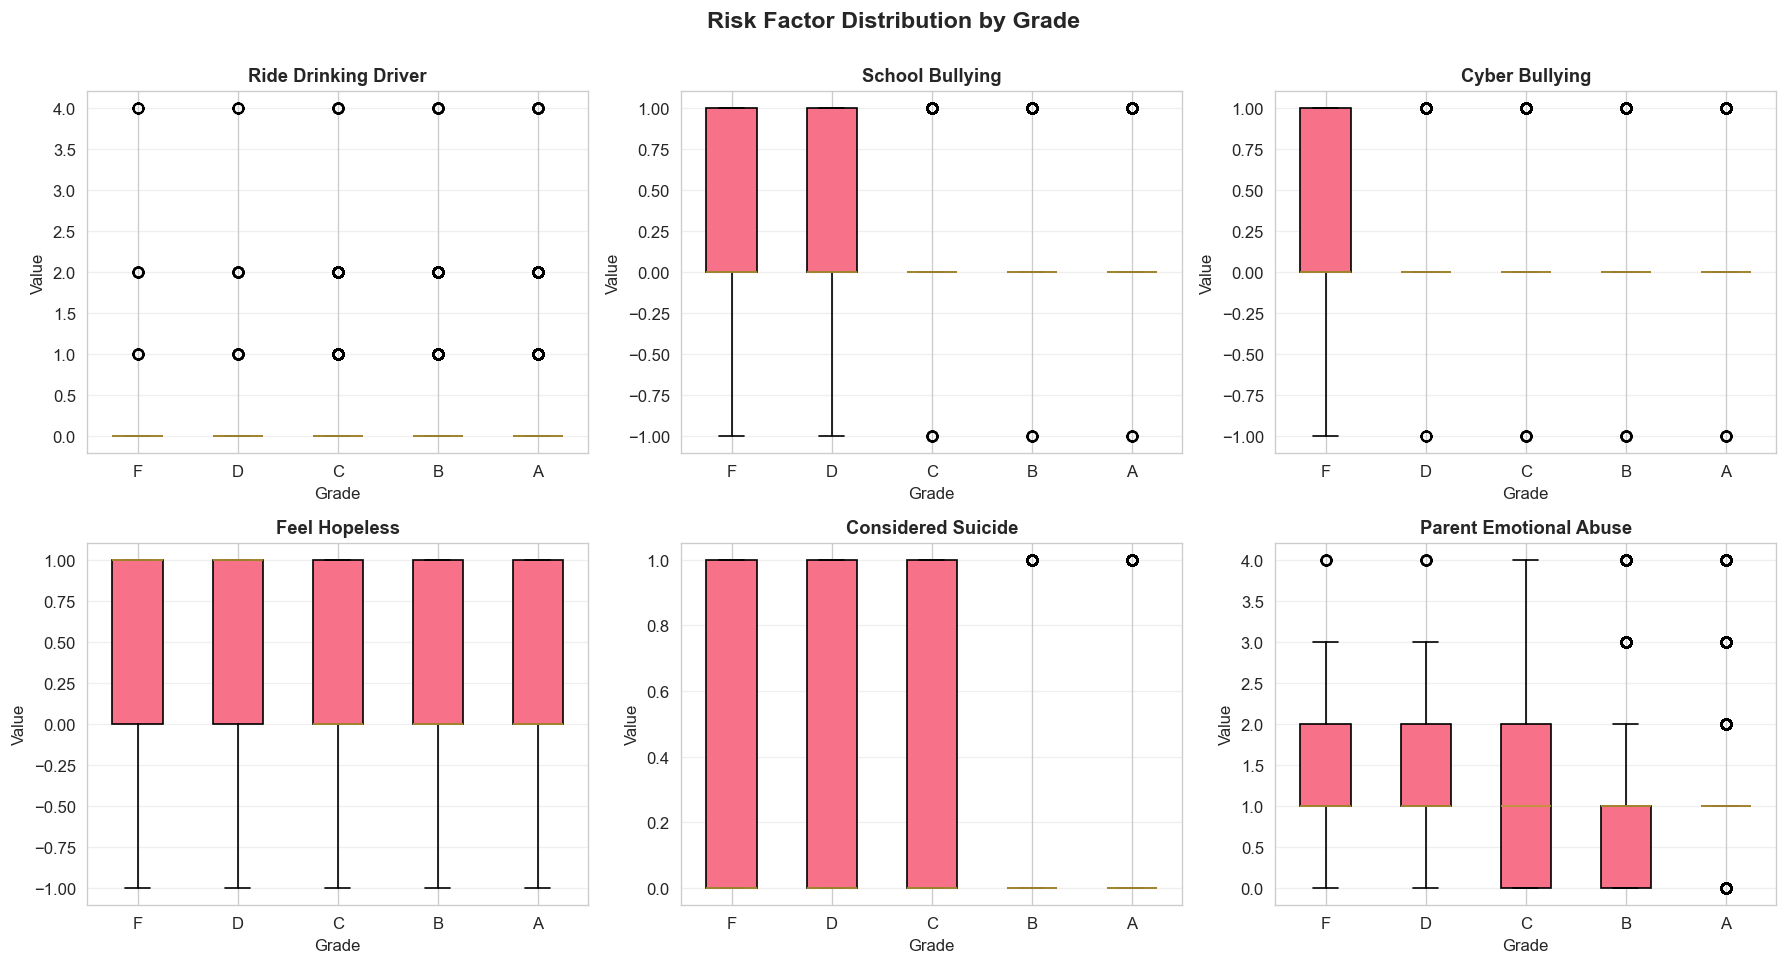

In [9]:
categorical_features = ['ride_drinking_driver', 'school_bullying', 'cyber_bullying', 
                       'feel_hopeless', 'considered_suicide', 'parent_emotional_abuse']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, feature in enumerate(categorical_features):
    ax = axes[idx]
    data_by_grade = [df[df['grade'] == g][feature].dropna().values for g in sorted(df['grade'].unique())]
    feature_series = pd.to_numeric(df[feature].replace({'Yes': 1, 'No': 0}), errors='coerce')
    data_by_grade = [feature_series[df['grade'] == g].dropna().values for g in sorted(df['grade'].unique())]
    bp = ax.boxplot(data_by_grade, labels=[grade_map[int(g)] for g in sorted(df['grade'].unique())], patch_artist=True)
    ax.set_title(f'{feature.replace("_", " ").title()}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Grade')
    ax.set_ylabel('Value')
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Risk Factor Distribution by Grade', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Alcohol Use Analysis

In [10]:
students_count = len(df)
drink = (df['alcohol_frequency'] > 0).sum()
not_drink = (df['alcohol_frequency'] == 0).sum()
drinker_percentage = (drink / students_count) * 100
print(f"\nTotal Students: {students_count:,}")
print(f"Ever Consumed Alcohol: {drink:,} ({drinker_percentage:.3f}%)")
print(f"Never Consumed Alcohol: {not_drink:,} ({(not_drink/students_count)*100:.3f}%)")


Total Students: 15,694
Ever Consumed Alcohol: 1,385 (8.825%)
Never Consumed Alcohol: 14,309 (91.175%)


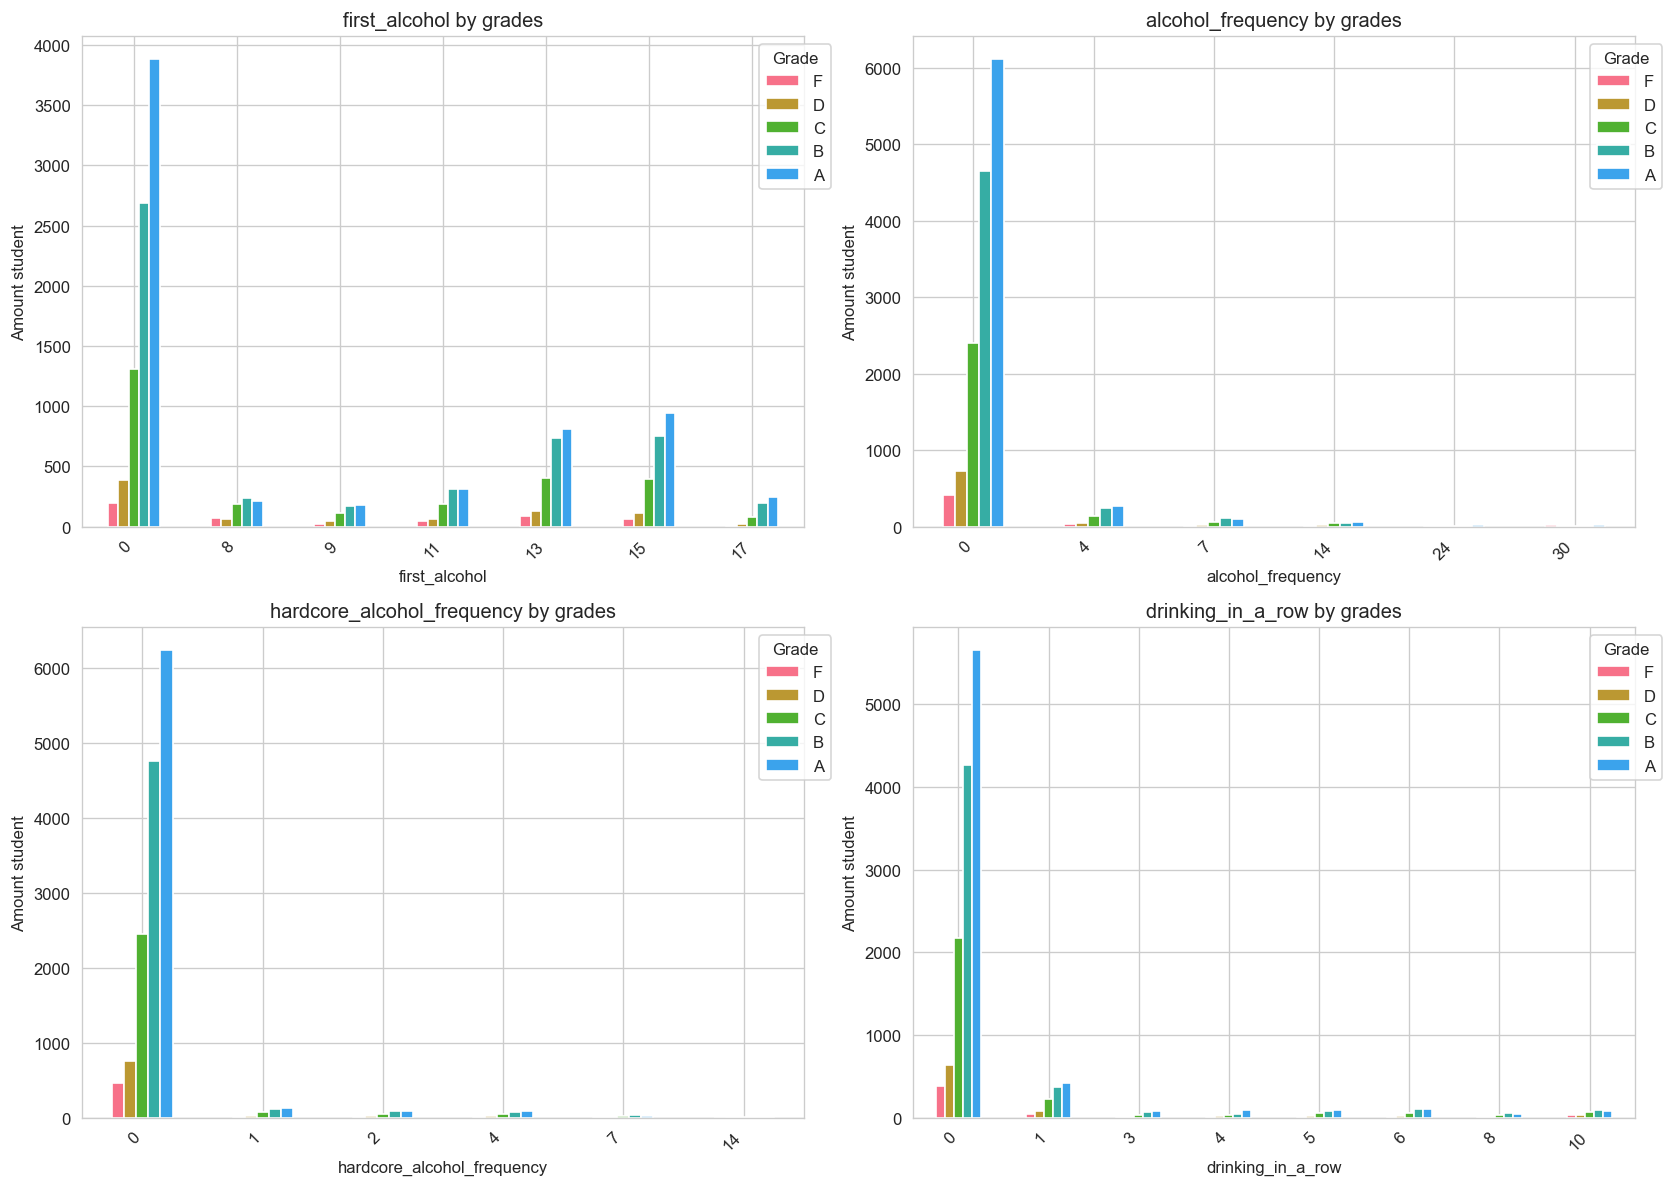

In [11]:
alcohol_cols = ['first_alcohol', 'alcohol_frequency', 'hardcore_alcohol_frequency', 'drinking_in_a_row']

# check unique values of each col before map laew na
labels_map = {
    'first_alcohol': {
        0:'Never', 8:'less than 8 years', 9:'9-10 years', 11:'11-12 years',
        13:'13-14 years', 15:'15-16 years', 17:'more than 17 years'
    },
    'alcohol_frequency': {
        0:'0 days', 4:'3-5 days', 7:'6-9 days',
        14:'10-19 days', 24:'20-29 days', 30:'All 30 days'
    },
    'hardcore_alcohol_frequency': {
        0:'0 days', 1:'1 day', 2:'2 days', 4:'3-5 days',
        7:'6-9 days', 14:'10-19 days'
    },
    'drinking_in_a_row': {
        0:'Did not drink', 1:'1-2 drinks', 3:'3 drinks', 4:'4 drinks',
        5:'5 drinks', 6:'6-7 drinks', 8:'8-9 drinks',10:'≥10 drinks'
    }
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(alcohol_cols):
    df.groupby([col, 'grade']).size().unstack().rename(columns=grade_map).plot(
        kind='bar',
        ax=axes[i])
    axes[i].set_title(f'{col} by grades')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Amount student')
    axes[i].legend(title='Grade', bbox_to_anchor=(1.05, 1))
    axes[i].set_xticklabels(labels_map[col], rotation=45, ha='right')

plt.tight_layout()
plt.show()

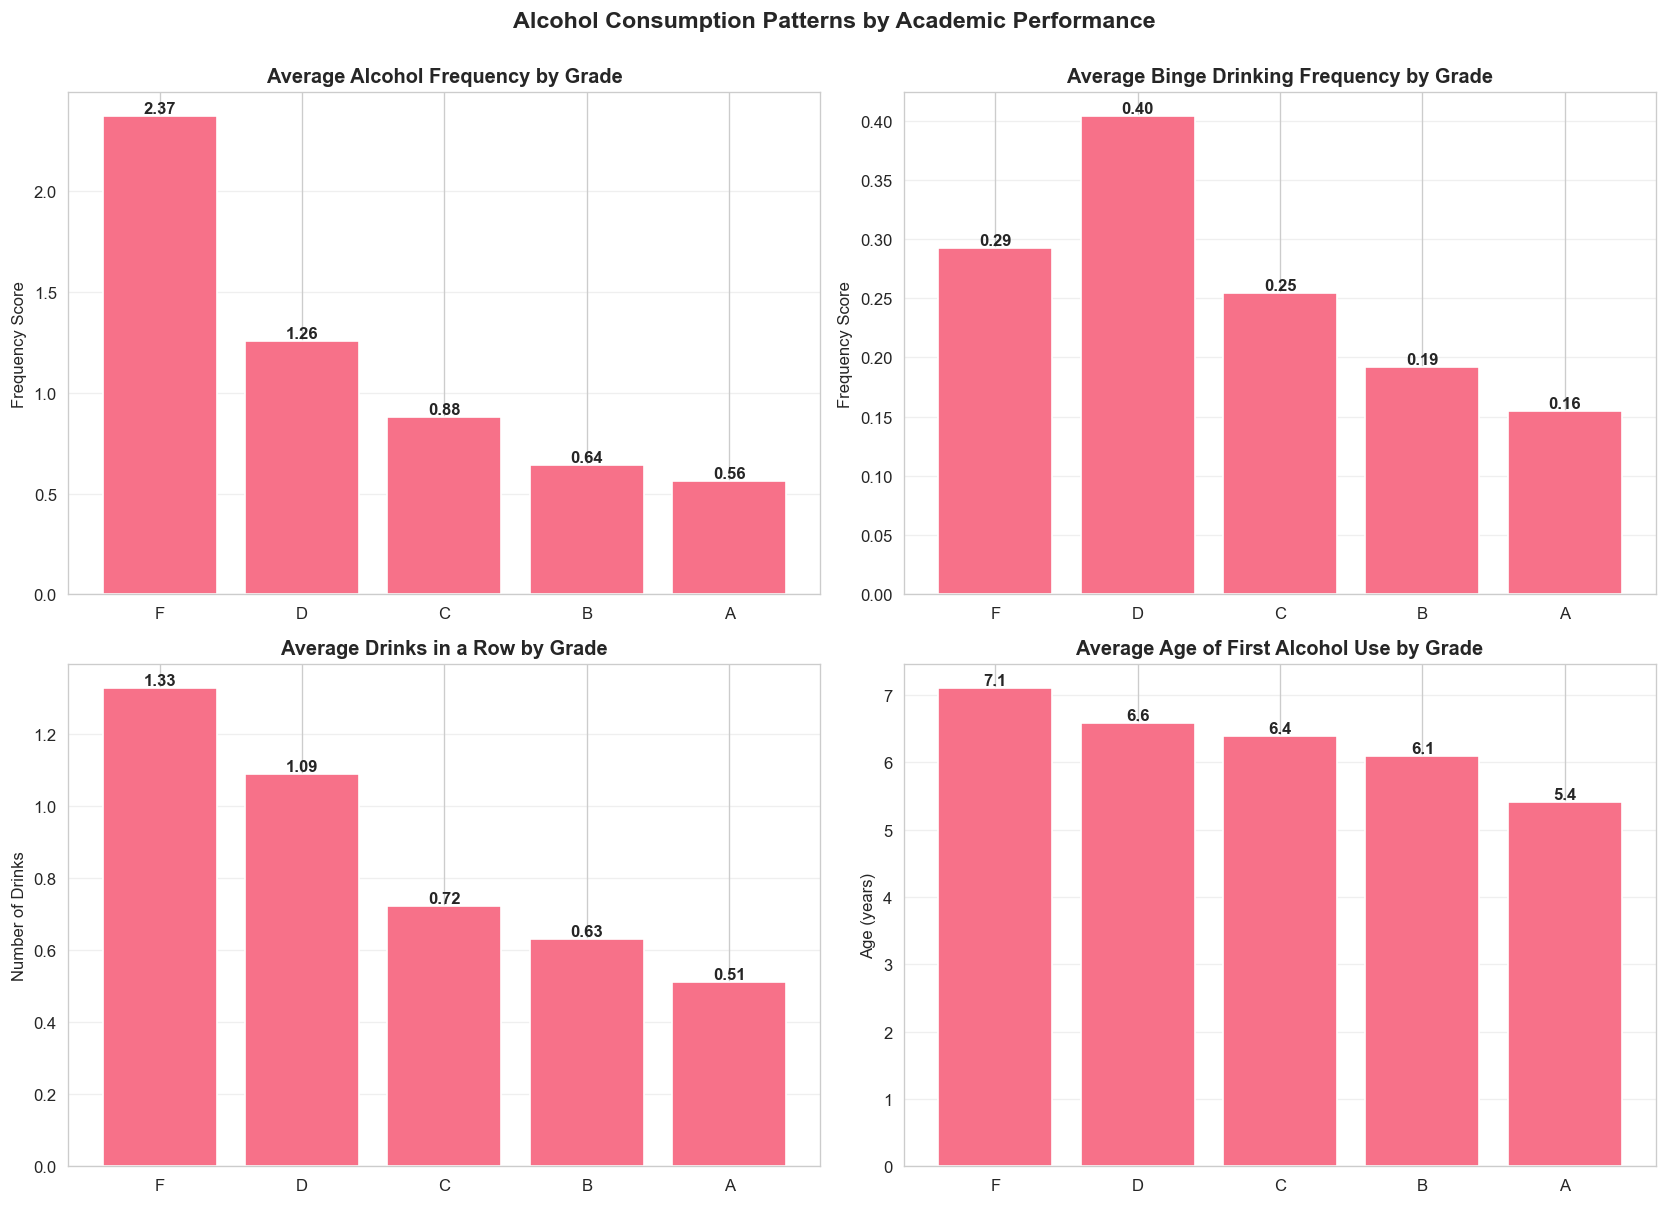

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
alcohol_freq_by_grade = df.groupby('grade')['alcohol_frequency'].mean()
alcohol_freq_by_grade.index = [grade_map[int(g)] for g in alcohol_freq_by_grade.index]
bars = ax.bar(alcohol_freq_by_grade.index, alcohol_freq_by_grade.values)
ax.set_title('Average Alcohol Frequency by Grade', fontweight='bold', fontsize=12)
ax.set_ylabel('Frequency Score')
ax.grid(alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax = axes[0, 1]
binge_by_grade = df.groupby('grade')['hardcore_alcohol_frequency'].mean()
binge_by_grade.index = [grade_map[int(g)] for g in binge_by_grade.index]
bars = ax.bar(binge_by_grade.index, binge_by_grade.values)
ax.set_title('Average Binge Drinking Frequency by Grade', fontweight='bold', fontsize=12)
ax.set_ylabel('Frequency Score')
ax.grid(alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax = axes[1, 0]
drinks_row_by_grade = df.groupby('grade')['drinking_in_a_row'].mean()
drinks_row_by_grade.index = [grade_map[int(g)] for g in drinks_row_by_grade.index]
bars = ax.bar(drinks_row_by_grade.index, drinks_row_by_grade.values)
ax.set_title('Average Drinks in a Row by Grade', fontweight='bold', fontsize=12)
ax.set_ylabel('Number of Drinks')
ax.grid(alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.2f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax = axes[1, 1]
first_alcohol_by_grade = df.groupby('grade')['first_alcohol'].mean()
first_alcohol_by_grade.index = [grade_map[int(g)] for g in first_alcohol_by_grade.index]
bars = ax.bar(first_alcohol_by_grade.index, first_alcohol_by_grade.values)
ax.set_title('Average Age of First Alcohol Use by Grade', fontweight='bold', fontsize=12)
ax.set_ylabel('Age (years)')
ax.grid(alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Alcohol Consumption Patterns by Academic Performance', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

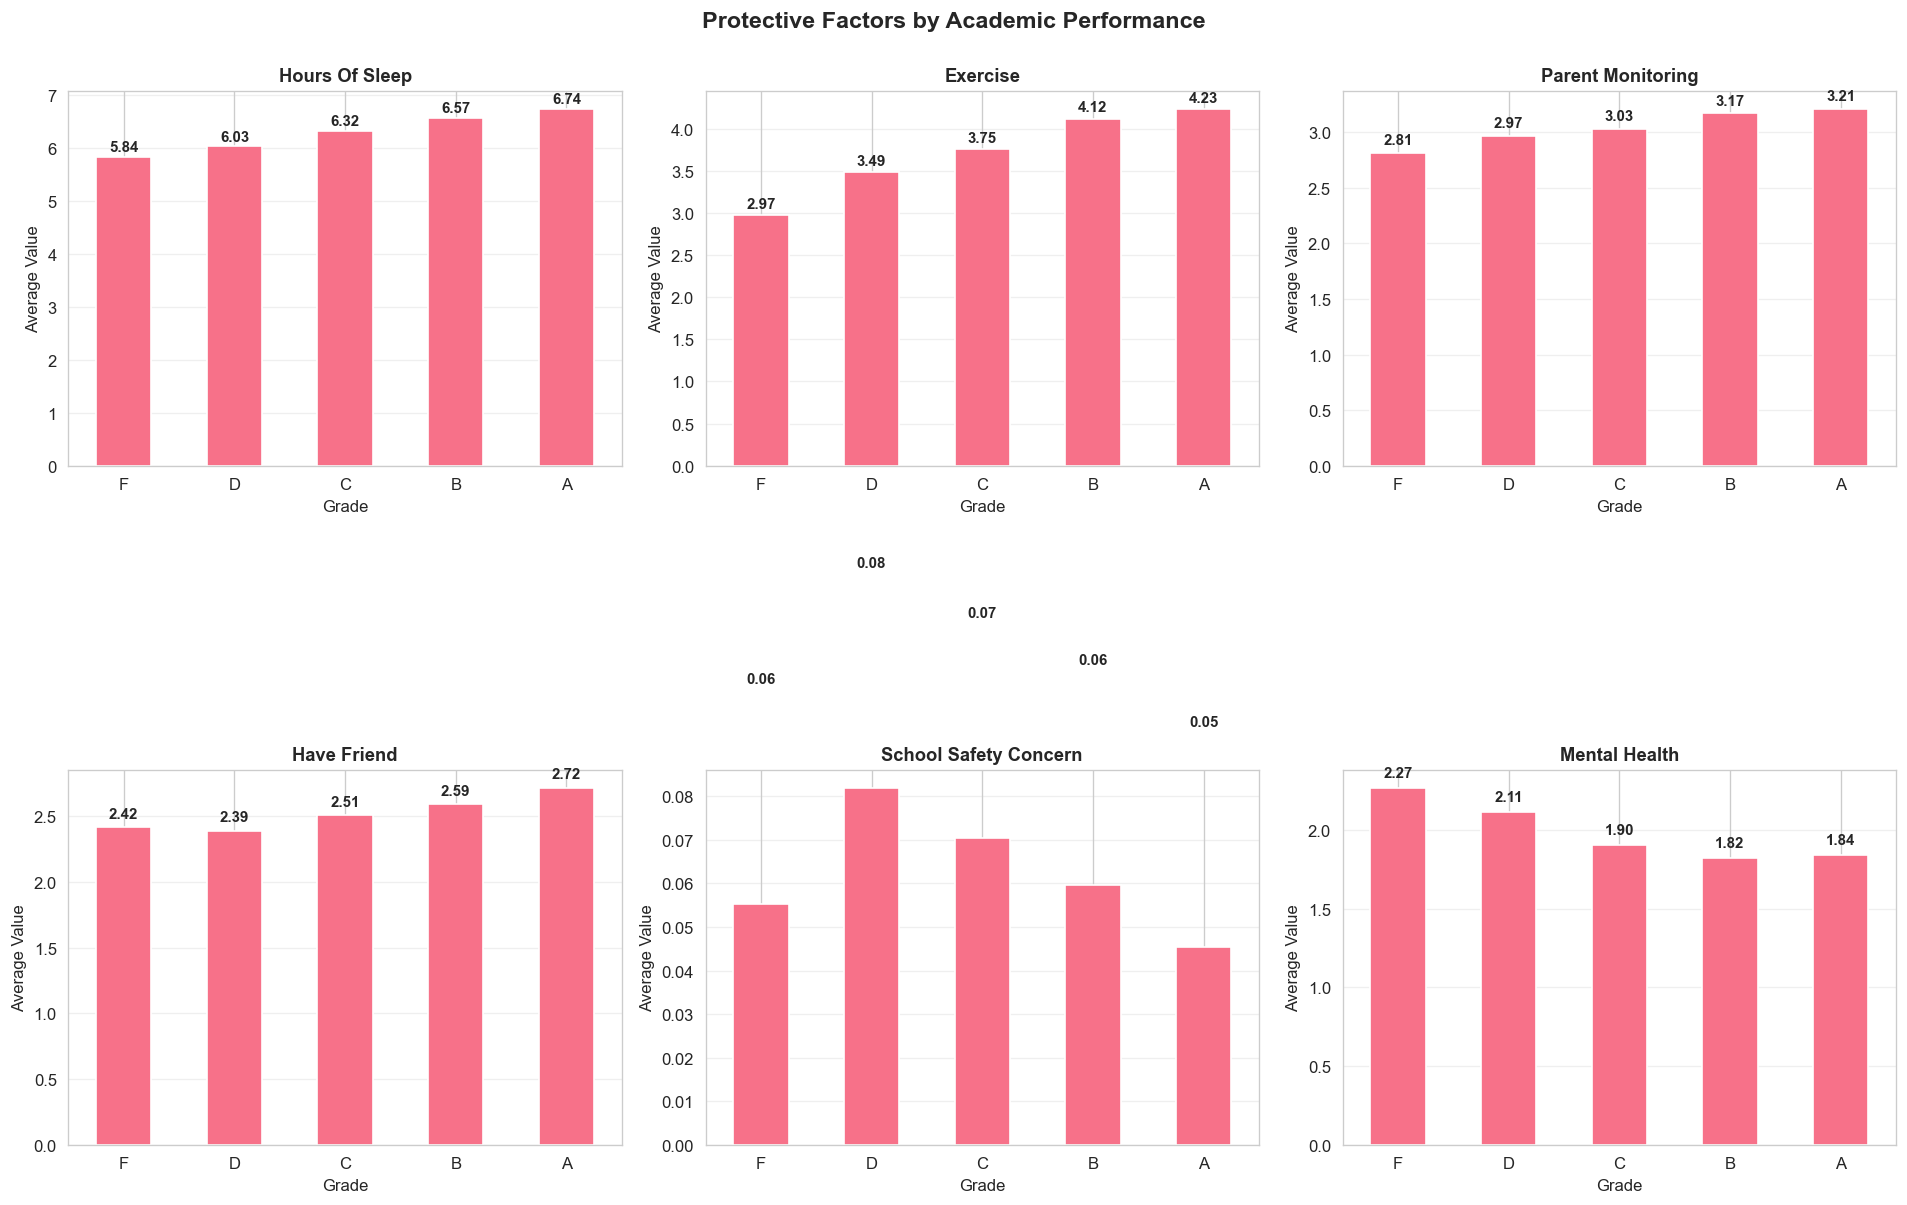

In [13]:
summary_cols = ['hours_of_sleep', 'exercise', 'alcohol_frequency', 'mental_health', 
                'social_media', 'school_safety_concern', 'parent_monitoring', 'have_friend',
                'school_bullying', 'feel_hopeless', 'parent_emotional_abuse']

summary_stats = df.groupby('grade')[summary_cols].mean()
summary_stats.index = [grade_map[int(g)] for g in summary_stats.index]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

protection_factors = ['hours_of_sleep', 'exercise', 'parent_monitoring', 'have_friend', 'school_safety_concern', 'mental_health']
for idx, col in enumerate(protection_factors):
    ax = axes[idx]
    summary_stats[col].plot(kind='bar', ax=ax)
    ax.set_title(f'{col.replace("_", " ").title()}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Grade')
    ax.set_ylabel('Average Value')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(summary_stats[col].values):
        ax.text(i, v + 0.05, f'{v:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Protective Factors by Academic Performance', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()